<a href="https://colab.research.google.com/github/MiksterBerlin/Bank-Deposit/blob/This%26That/Comparison_of_Classifier_Bank_data062225.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
import plotly.express as px
import plotly.graph_objects as go
from sklearn import metrics
import time

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv('/content/drive/MyDrive/bank-additional-full.csv', sep = ';')
df1 = pd.read_csv('/content/drive/MyDrive/bank-additional.csv', sep = ';')


In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Buisness Objective**
Marketing Bank Products over the phone.

The goal is to define the features that predict the likelyhood that a client subscribes a term deposit.
This will help to target phone calls to clients to maximize the outcome.
This will decrease the time wasted on phone calls with low likelyhood of subscriptions and increase the number of clients that subscribe to a term deposit in the same timeframe.



### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [9]:
df = df.drop(columns = ['duration'])
df1 = df1.drop(columns = ['duration'])



In [10]:
df['pdays'].value_counts()

def previous_cont(series):
    if series == 999:
        return -1
    else:
        return series

df['previous_count'] = df['pdays'].apply(previous_cont)
df1['previous_count'] = df1['pdays'].apply(previous_cont)

df = df.drop(columns = ['pdays'])
df1 = df1.drop(columns = ['pdays'])

In [12]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


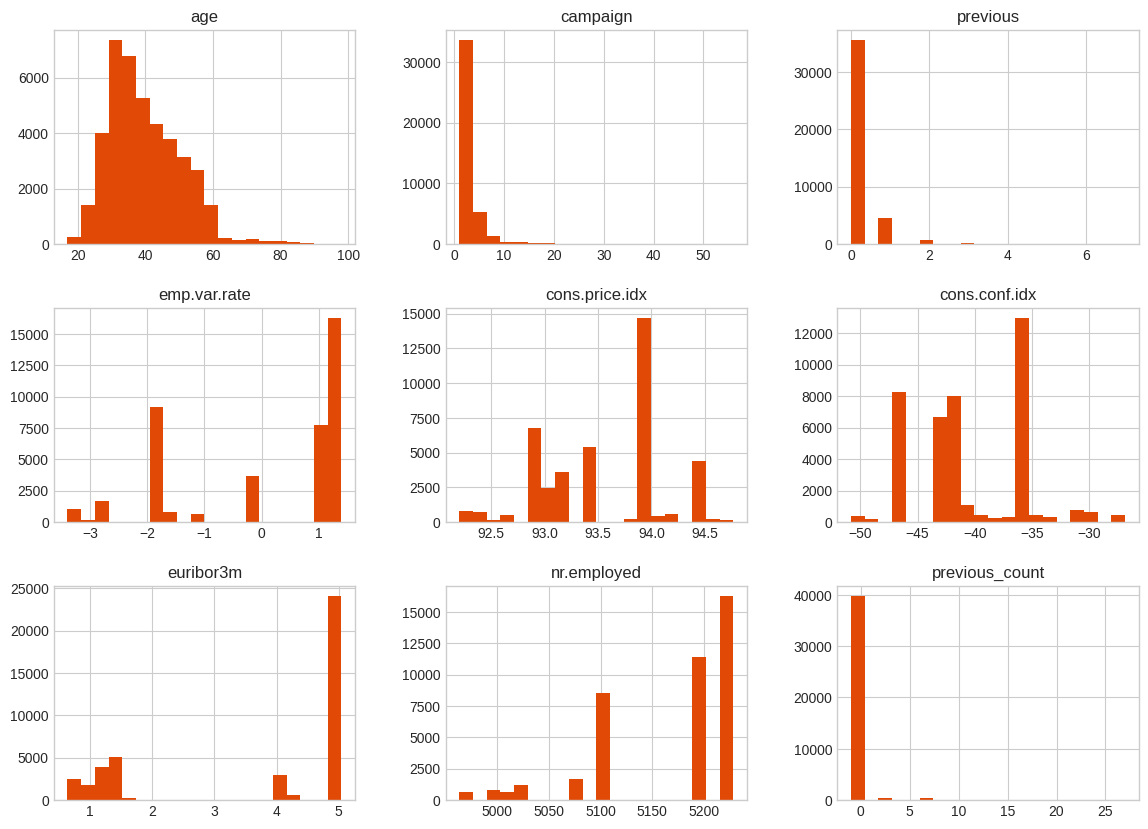

In [15]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

df.hist(bins=20, figsize=(14,10), color='#E14906')
plt.show()

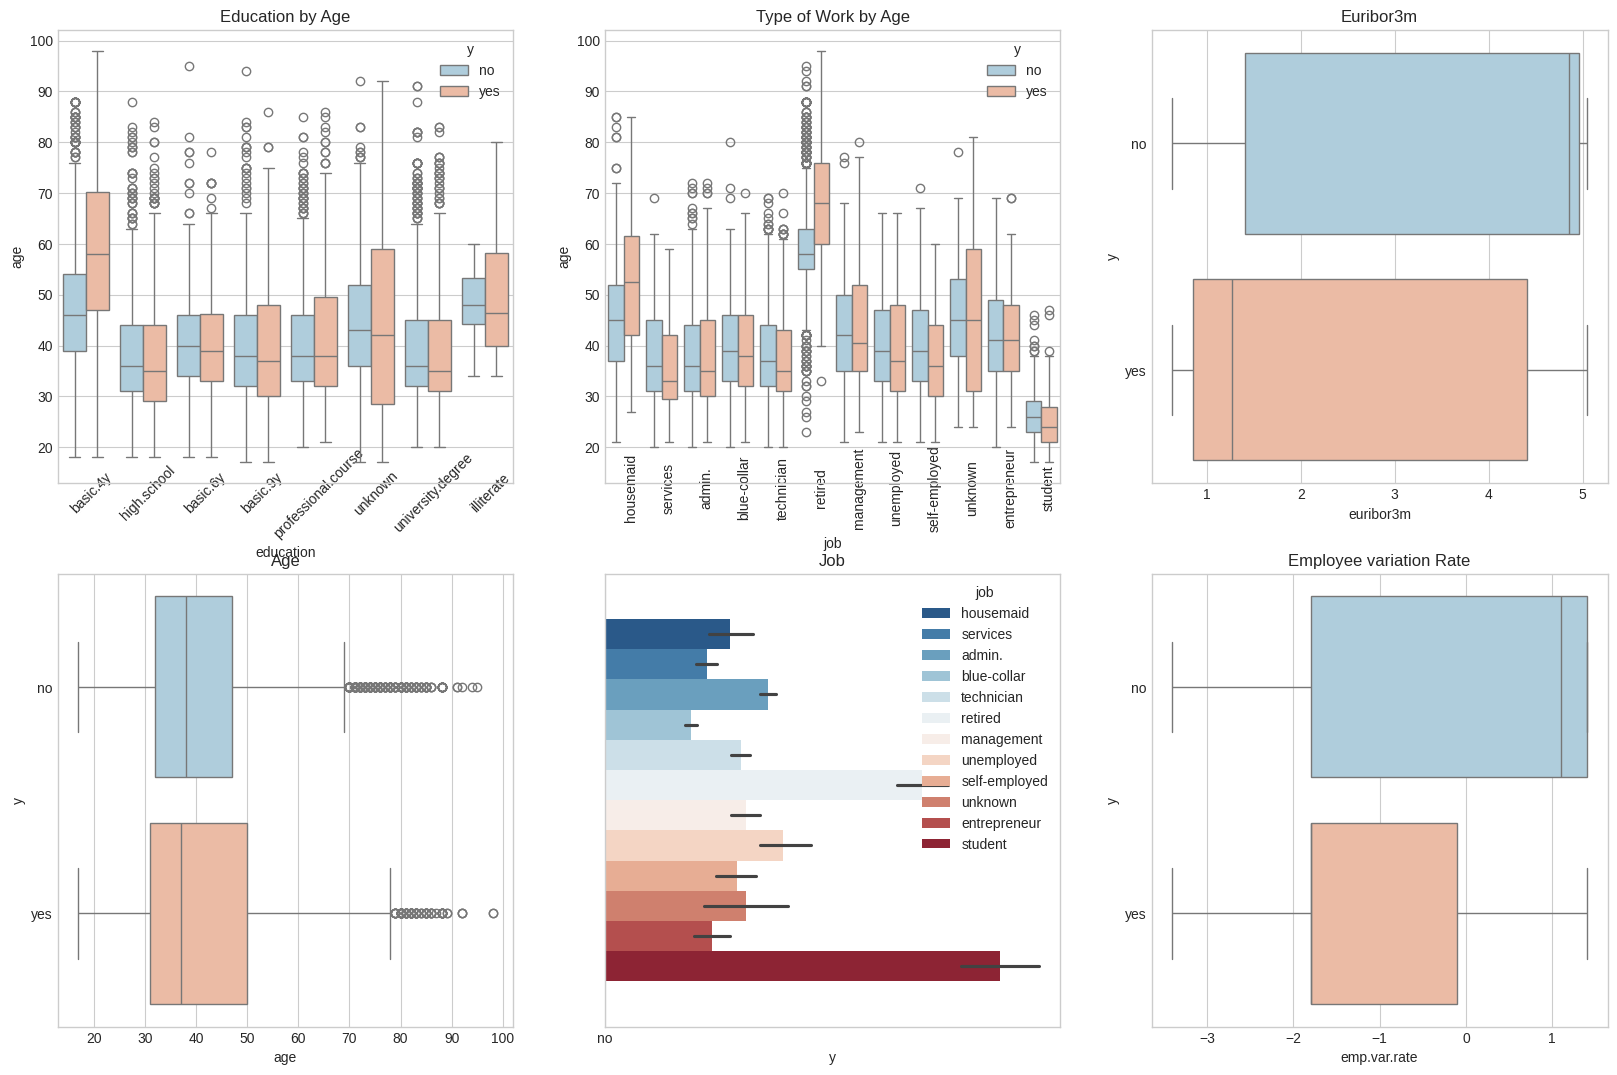

In [36]:
# Checking dependencies
fig = plt.figure(figsize=(20,20))
ax1 = fig.add_subplot(331)
ax2 = fig.add_subplot(332)
ax3 = fig.add_subplot(333)
ax4 = fig.add_subplot(334)
ax5 = fig.add_subplot(335)
ax6 = fig.add_subplot(336)

g = sns.boxplot(x="education", y="age", hue="y",
                    data=df, palette="RdBu_r", ax=ax1)
g.set_title("Education by Age")
g.set_xticklabels(df["education"].unique(), rotation=45, rotation_mode="anchor")


g1 = sns.boxplot(x="job", y="age", hue="y",
                 data=df, palette="RdBu_r", ax=ax2)

g1.set_xticklabels(df["job"].unique(), rotation=90, rotation_mode="anchor")
g1.set_title("Type of Work by Age")


g2 = sns.boxplot(data=df, x="euribor3m", y='y', palette="RdBu_r", ax=ax3)
g2.set_title("Euribor3m")


g3 = sns.boxplot(data=df, x="age", y="y", palette="RdBu_r", ax=ax4)
g3.set_title("Age")


g4 = sns.barplot(data=df, x="y", hue="job", palette="RdBu_r", ax=ax5)
g4.set_title("Job")


g5 = sns.boxplot(data=df, x="emp.var.rate", y="y", palette="RdBu_r", ax=ax6)
g5.set_title("Employee variation Rate")

plt.show()

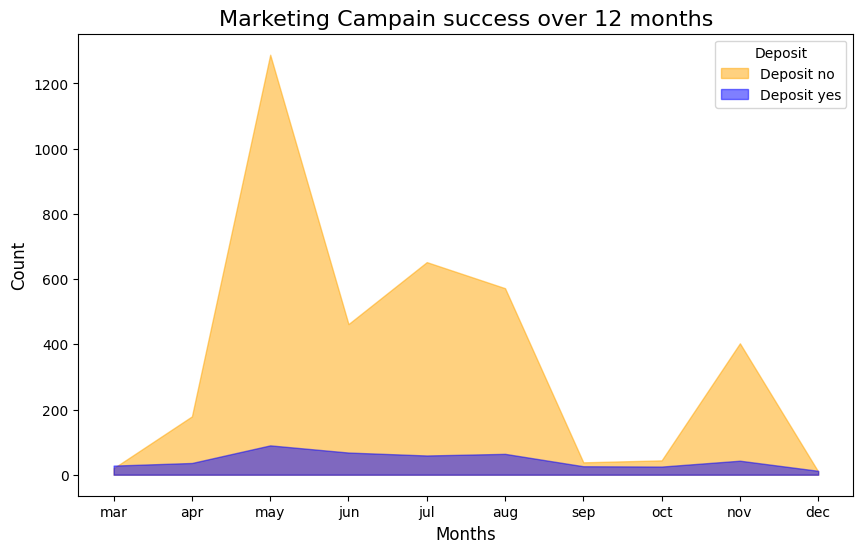

In [80]:
#Plotting the distribution of Yes and No answers over the year

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Figure specifics
df1_pivot = df1.groupby(['month', 'y']).size().unstack(fill_value=0)
df1_pivot = df1_pivot.reindex(month_order)
plt.figure(figsize=(10, 6))
colors = ['orange', 'blue']


for i, column in enumerate(df1_pivot.columns):
    plt.fill_between(df1_pivot.index, df1_pivot[column], alpha=0.5, color=colors[i], label=f'Deposit {column}')


plt.title('Marketing Campain success over 12 months', fontsize=16)
plt.xlabel('Months', fontsize=12)
plt.ylabel('Count', fontsize=12)

# legend
plt.legend(title='Deposit')

# plot
plt.show()

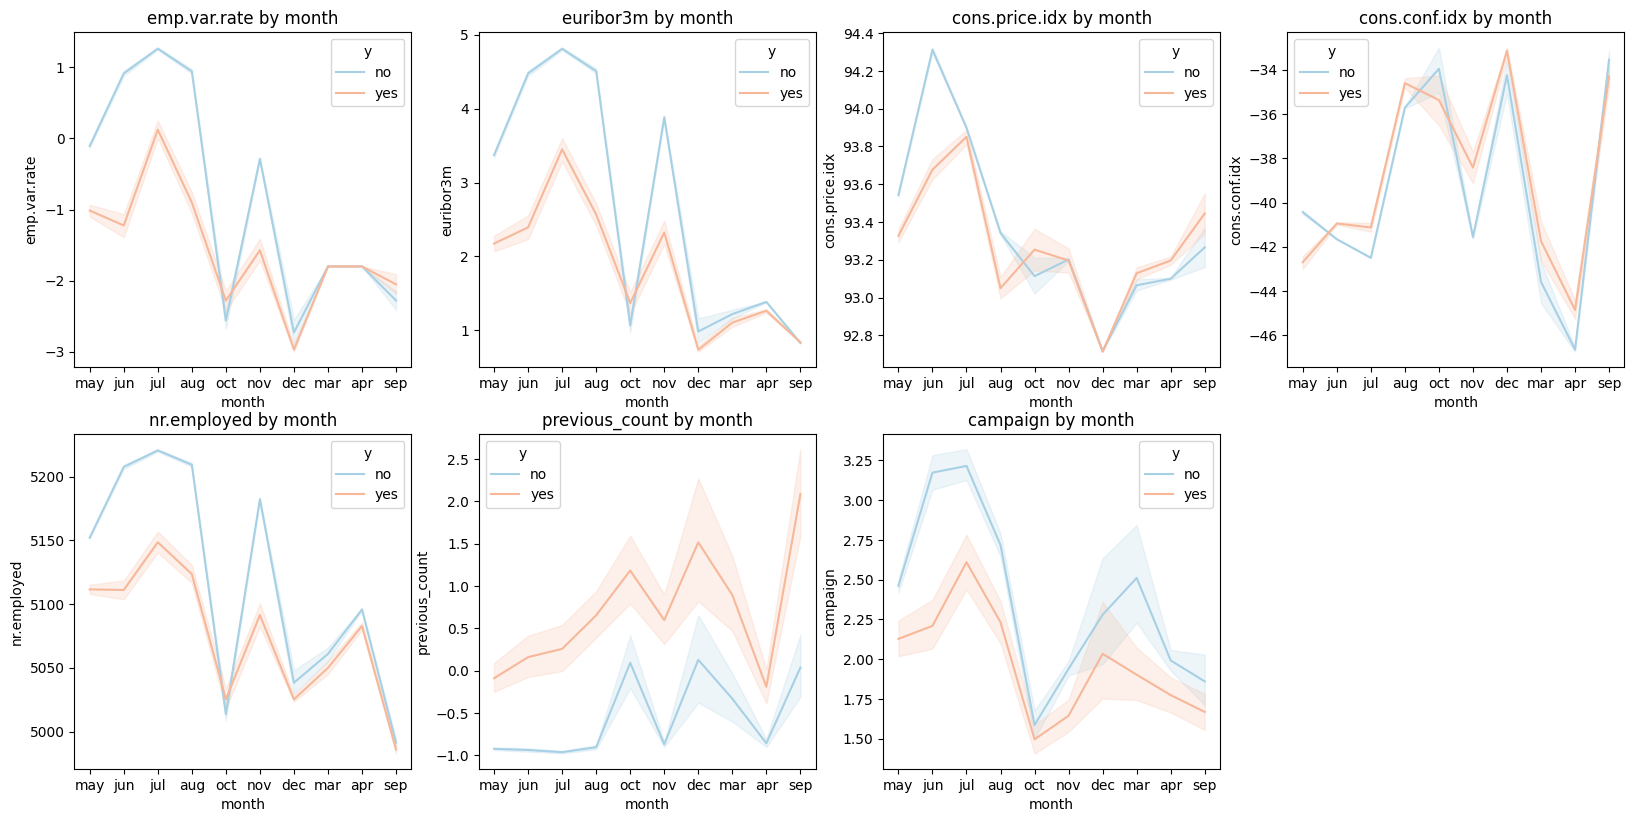

In [82]:
# Checking dependencies
fig = plt.figure(figsize=(20,20))
ax1 = fig.add_subplot(441)
ax2 = fig.add_subplot(442)
ax3 = fig.add_subplot(443)
ax4 = fig.add_subplot(444)
ax5 = fig.add_subplot(445)
ax6 = fig.add_subplot(446)
ax7 = fig.add_subplot(447)


#look at employment Variation rate by month
g = sns.lineplot(x='month', y='emp.var.rate', hue="y", data=df, palette="RdBu_r", ax=ax1)
g.set_title("emp.var.rate by month")

# euribor: The interest rates do provide the basis for the price and interest rates of all kinds of financial products like interest rate swaps, interest rate futures, saving accounts and mortgages.
g1 = sns.lineplot(x='month', y='euribor3m', hue="y", data=df, palette="RdBu_r", ax=ax2)
g1.set_title("euribor3m by month")

# consumer price index by month
g2 = sns.lineplot(data=df, x="month", y="cons.price.idx", hue="y", palette="RdBu_r", ax=ax3)
g2.set_title("cons.price.idx by month")

#consumer confidence index
g3 = sns.lineplot(data=df, x="month", y="cons.conf.idx", hue="y",palette="RdBu_r", ax=ax4)
g3.set_title("cons.conf.idx by month")

# Nr of employees
g4 = sns.lineplot(data=df, x="month", y="nr.employed", hue="y",palette="RdBu_r", ax=ax5)
g4.set_title("nr.employed by month")

g5 = sns.lineplot(data=df, x="month", y="previous_count", hue="y",palette="RdBu_r", ax=ax6)
g5.set_title("previous_count by month")


g6 = sns.lineplot(data=df, x="month", y="campaign", hue="y",palette="RdBu_r", ax=ax7)
g6.set_title("campaign by month")



plt.show()





In [13]:
#separate cathegorical and nummerical variables for processing
cathegorical_features = ['job', 'marital', 'education', 'housing', 'loan', 'day_of_week', 'poutcome', 'education', 'default', 'month']
nummeric_features = ['age', 'previous_count','emp.var.rate', 'cons.price.idx', 'cons.conf.idx','euribor3m']


In [14]:
# Select only the numeric columns for the pivot table
numeric_df = df[nummeric_features + ['y']]

# Create the pivot table using only the numeric features as values
table1 = pd.pivot_table(data=numeric_df, index=['y'])
table1

,age,cons.conf.idx,cons.price.idx,emp.var.rate,euribor3m,previous_count
y,,,,,,
no,39.911185,-40.593097,93.603757,0.248875,3.811491,-0.892142
yes,40.913147,-39.789784,93.354386,-1.233448,2.123135,0.440733


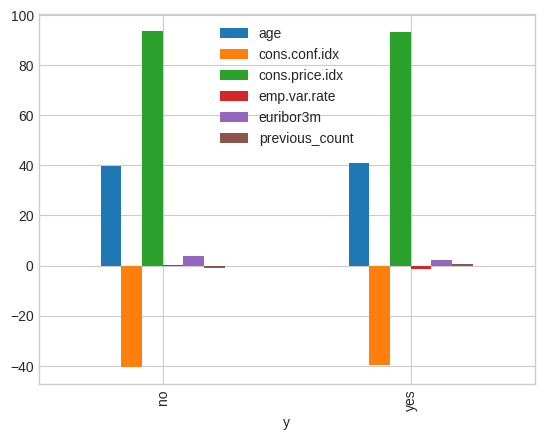

In [159]:
table1.plot(kind='bar')
plt.show()

<Axes: >

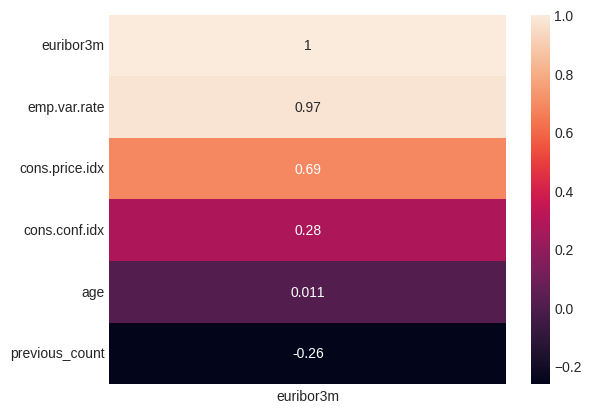

In [15]:

numeric_df2 = df[nummeric_features]
sns.heatmap(numeric_df2.corr()[['euribor3m']].sort_values(by = 'euribor3m', ascending = False), annot = True)

<Axes: >

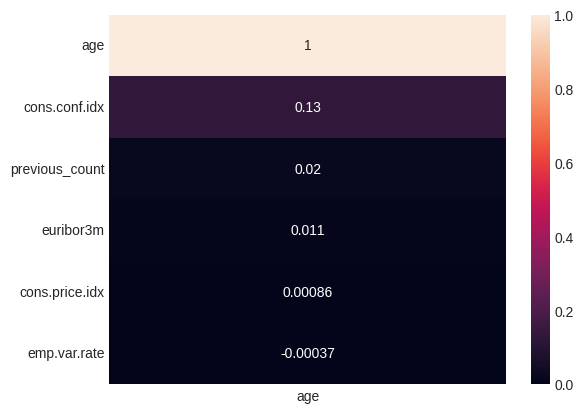

In [37]:
numeric_df2 = df[nummeric_features]
sns.heatmap(numeric_df2.corr()[['age']].sort_values(by = 'age', ascending = False), annot = True)

In [16]:
# Select only the numeric columns for the pivot table
numeric_df = df[nummeric_features + ['month']]

# Create the pivot table using only the numeric features as values
table2 = pd.pivot_table(data=numeric_df, index=['month'])
table2

,age,cons.conf.idx,cons.price.idx,emp.var.rate,euribor3m,previous_count
month,,,,,,
apr,40.593845,-46.273632,93.119558,-1.800000,1.361070,-0.719605
aug,41.644221,-35.597184,93.311065,0.747151,4.300623,-0.737779
dec,47.307692,-33.708791,92.715363,-2.846154,0.865319,0.807692
jul,39.035545,-42.370170,93.894923,1.158921,4.685678,-0.850990
jun,39.766077,-41.579428,94.245402,0.688379,4.256908,-0.820233
mar,40.778388,-42.650549,93.097330,-1.800000,1.162745,0.289377
may,39.031084,-40.579272,93.528882,-0.164972,3.293665,-0.868110
nov,40.965618,-41.238747,93.200943,-0.418483,3.723123,-0.719581
oct,44.171309,-34.580919,93.175107,-2.438579,1.200123,0.572423


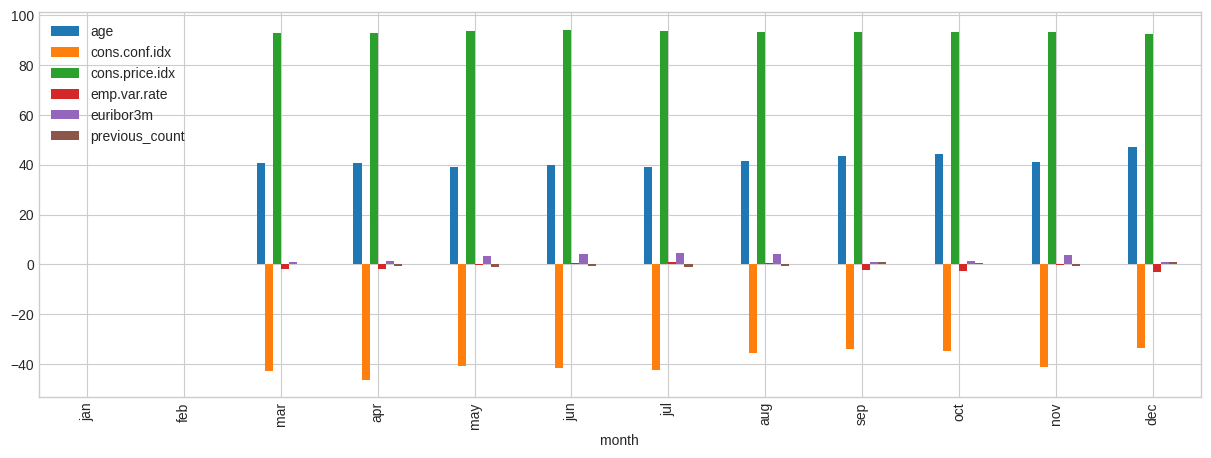

In [19]:
ax = table2.reindex(month_order).plot(kind='bar')
fig = ax.figure
fig.set_size_inches(15, 5)
plt.show()

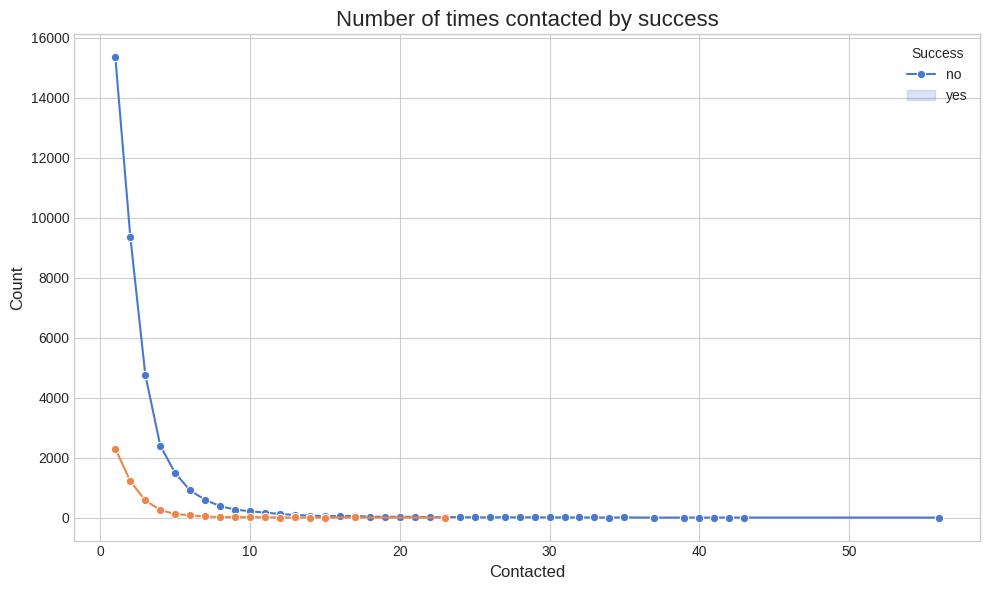

In [163]:
# Number of times contacted by success
contact_avg = df.groupby(['campaign', 'y']).size().reset_index(name='count')

# Figure specifics
plt.figure(figsize=(10, 6))

# Lineplot
sns.lineplot(data=contact_avg, x='campaign', y='count', hue='y', marker='o', palette='muted')


# Number of times contacted by success
plt.title('Number of times contacted by success', fontsize=16)
plt.xlabel('Contacted', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Success', labels=['no', 'yes'])

# Plotting
plt.tight_layout()
plt.show()

In [11]:
#Separate the target from the features for SHORT dataset
X1 = df1.drop(columns = ['y', 'month', 'emp.var.rate', 'cons.price.idx', 'age' ])
y1 = df1['y']

In [12]:
#Separate the target from the features for SHORT dataset
X = df.drop(columns = ['y', 'month','emp.var.rate', 'cons.price.idx', 'age' ])
y = df['y']

In [13]:
#separate cathegorical and nummerical variables for processing
cathegorical_features1 = ['job', 'marital', 'education', 'housing', 'loan', 'day_of_week', 'poutcome', 'education', 'default']
nummeric_features1 = ['previous_count', 'cons.conf.idx', 'euribor3m', 'campaign']


In [14]:
#Provide instructions for how to transform each of the data types

preprocessor = make_column_transformer(
    (OneHotEncoder(), cathegorical_features1),
    (StandardScaler() , nummeric_features1)
)

In [15]:
# Create Pipeline
pipeline = make_pipeline(preprocessor)


In [16]:
X_transformed = pipeline.fit_transform(X)
X_transformed1 = pipeline.transform(X1)

print(X_transformed.shape, X_transformed1.shape)

(41188, 53) (4119, 53)


In [17]:
feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()

In [25]:
feature_names

array(['onehotencoder__job_admin.', 'onehotencoder__job_blue-collar',
       'onehotencoder__job_entrepreneur', 'onehotencoder__job_housemaid',
       'onehotencoder__job_management', 'onehotencoder__job_retired',
       'onehotencoder__job_self-employed', 'onehotencoder__job_services',
       'onehotencoder__job_student', 'onehotencoder__job_technician',
       'onehotencoder__job_unemployed', 'onehotencoder__job_unknown',
       'onehotencoder__marital_divorced',
       'onehotencoder__marital_married', 'onehotencoder__marital_single',
       'onehotencoder__marital_unknown',
       'onehotencoder__education_basic.4y',
       'onehotencoder__education_basic.6y',
       'onehotencoder__education_basic.9y',
       'onehotencoder__education_high.school',
       'onehotencoder__education_illiterate',
       'onehotencoder__education_professional.course',
       'onehotencoder__education_university.degree',
       'onehotencoder__education_unknown', 'onehotencoder__housing_no',
       'on

In [18]:
#Correlation matix to reduce features for analysis FULL & SHORT Dataset

from scipy.stats import pearsonr
#FULL dataset
# For simplicity, assuming it's a dense NumPy array or can be converted.
if not isinstance(X_transformed, np.ndarray):
    # Check if it's a sparse matrix before converting
    if hasattr(X_transformed, 'toarray'):
        Xtr = X_transformed.toarray() # Convert sparse matrix to dense if necessary
    # If it's neither ndarray nor sparse, print a warning or handle appropriately
    else:
        print("Warning: X is not a NumPy array or sparse matrix. Correlation might not be calculated correctly.")



# Ensure y is a NumPy array for consistent indexing, though pandas Series also works
if isinstance(y, pd.Series):
    y = y.values

# **Encode the target variable y1 to numerical values**
# Map 'yes' to 1 and 'no' to 0
y1_encoded = np.where(y == 'yes', 1, 0)

# Iterate through each column (feature) in Xand calculate the correlation with y1
# Assuming X has shape (n_samples, n_features)
n_features = Xtr.shape[1]

# Store results to sort later
correlation_results = []


print("Pearson Correlation Coefficients and p-values for each feature:")
for i in range(n_features):
    # Select the i-th column (feature) from X_transformed1
    feature_column = Xtr[:, i]

    # Calculate Pearson correlation between the feature and the target variable
    # Use the encoded target variable
    corr_coef, p_value = pearsonr(feature_column, y1_encoded)

    # Store the results along with the feature index (and potentially name)
    correlation_results.append({'feature_index': i, 'correlation': corr_coef, 'p_value': p_value})


# Let's sort by p-value in ascending order to find the most significant features first
sorted_results_by_pvalue = sorted(correlation_results, key=lambda x: x['p_value'])

# Sort by absolute correlation to see the strongest relationships regardless of direction:
sorted_results_by_abs_corr = sorted(correlation_results, key=lambda x: abs(x['correlation']), reverse=True)

print("\nSorted Pearson Correlation Coefficients and p-values (by absolute correlation, descending):")
# Print the sorted results
for result in sorted_results_by_abs_corr:
     feature_index = result['feature_index']
     corr_coef = result['correlation']
     p_value = result['p_value']
     feature_name = feature_names[feature_index] if 'feature_names' in globals() and len(feature_names) == n_features else f"Feature {feature_index}"
     print(f"  '{feature_name}': Correlation = {corr_coef:.4f}, p-value = {p_value:.4f}")



Pearson Correlation Coefficients and p-values for each feature:

Sorted Pearson Correlation Coefficients and p-values (by absolute correlation, descending):
  'onehotencoder__poutcome_success': Correlation = 0.3163, p-value = 0.0000
  'standardscaler__euribor3m': Correlation = -0.3078, p-value = 0.0000
  'standardscaler__previous_count': Correlation = 0.2790, p-value = 0.0000
  'onehotencoder__poutcome_nonexistent': Correlation = -0.1935, p-value = 0.0000
  'onehotencoder__default_no': Correlation = 0.0993, p-value = 0.0000
  'onehotencoder__default_unknown': Correlation = -0.0993, p-value = 0.0000
  'onehotencoder__job_student': Correlation = 0.0940, p-value = 0.0000
  'onehotencoder__job_retired': Correlation = 0.0922, p-value = 0.0000
  'onehotencoder__job_blue-collar': Correlation = -0.0744, p-value = 0.0000
  'standardscaler__campaign': Correlation = -0.0664, p-value = 0.0000
  'standardscaler__cons.conf.idx': Correlation = 0.0549, p-value = 0.0000
  'onehotencoder__marital_single

In [19]:

# Let's re-fetch the original feature names from the pipeline to be sure
original_feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()

# Get the indices of features to keep based on the correlation results
# These indices are relative to the original 56 features
valid_feature_indices_original = [result['feature_index'] for result in correlation_results if result['p_value'] <= 0.05 and result['feature_index'] < X_transformed.shape[1]]

# Select columns from the sparse matrix using integer indexing
# These operations correctly use the indices relative to the X_transformed matrices
X = X_transformed[:, valid_feature_indices_original]
X1 = X_transformed1[:, valid_feature_indices_original] # Apply the same selection to X_transformed1

# Update feature_names to reflect the names of the selected features
feature_names2 = original_feature_names[valid_feature_indices_original]


# Separate the target from the features for FULL dataset (y is already defined correctly)
y = df['y']

print(f"Original number of features: {X_transformed.shape[1]}")
print(f"Number of features to drop: {X_transformed.shape[1] - len(valid_feature_indices_original)}")
print(f"Number of features after dropping: {X.shape[1]}")
print(f"Selected feature names: {list(feature_names)}...")

Original number of features: 53
Number of features to drop: 20
Number of features after dropping: 33
Selected feature names: ['onehotencoder__job_admin.', 'onehotencoder__job_blue-collar', 'onehotencoder__job_entrepreneur', 'onehotencoder__job_housemaid', 'onehotencoder__job_management', 'onehotencoder__job_retired', 'onehotencoder__job_self-employed', 'onehotencoder__job_services', 'onehotencoder__job_student', 'onehotencoder__job_technician', 'onehotencoder__job_unemployed', 'onehotencoder__job_unknown', 'onehotencoder__marital_divorced', 'onehotencoder__marital_married', 'onehotencoder__marital_single', 'onehotencoder__marital_unknown', 'onehotencoder__education_basic.4y', 'onehotencoder__education_basic.6y', 'onehotencoder__education_basic.9y', 'onehotencoder__education_high.school', 'onehotencoder__education_illiterate', 'onehotencoder__education_professional.course', 'onehotencoder__education_university.degree', 'onehotencoder__education_unknown', 'onehotencoder__housing_no', 'on

In [20]:
from imblearn.over_sampling import SMOTE
smote1=SMOTE(sampling_strategy='minority')
XRes1, yRes1=smote1.fit_resample(X, y)
yRes1.value_counts()

,count
y,
no,36548
yes,36548


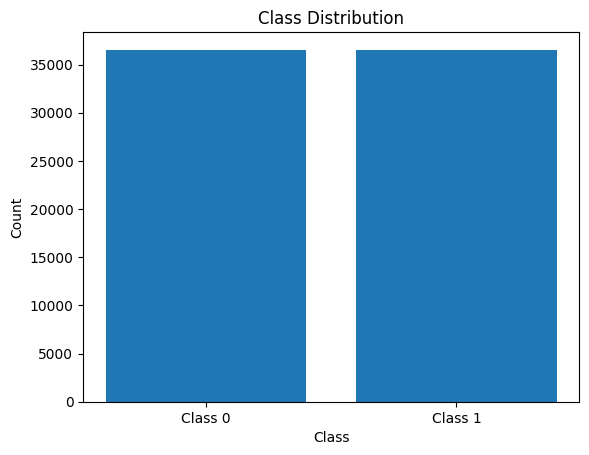

In [21]:
count_class = yRes1.value_counts() # Count the occurrences of each class
plt.bar(count_class.index, count_class.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(count_class.index, ['Class 0', 'Class 1'])
plt.show()

In [22]:
#Oversampling for SHORT Dataset
smote1=SMOTE(sampling_strategy='minority')
XRes2, yRes2=smote1.fit_resample(X1, y1)
yRes2.value_counts()

,count
y,
no,3668
yes,3668


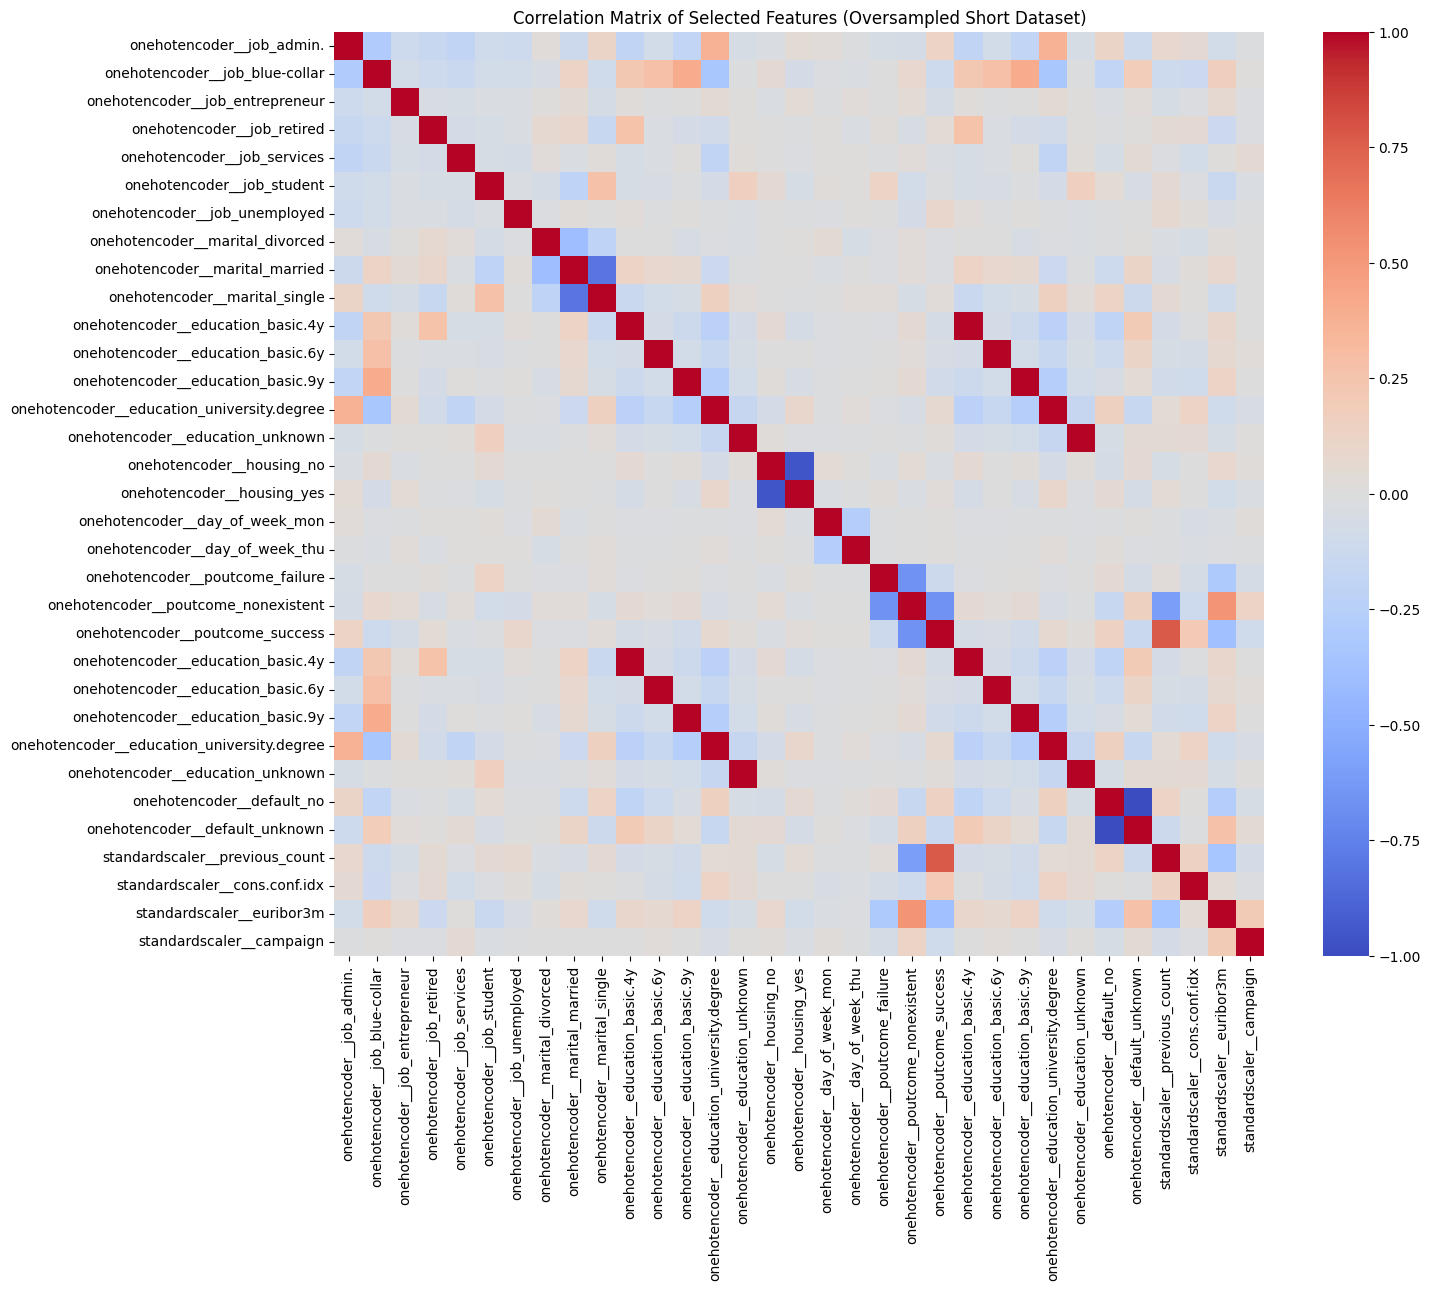

In [85]:
import pandas as pd
import numpy as np

# Convert the sparse matrix to a dense NumPy array
XRes2_dense = XRes2.toarray()

# Convert the dense NumPy array to a pandas DataFrame for easy correlation calculation
try:
    # Assuming feature_names2 corresponds to the columns in XRes2
    XRes2_df = pd.DataFrame(XRes2_dense, columns=feature_names2)
except NameError:
    print("Warning: feature_names2 not found. Using generic column names.")
    XRes2_df = pd.DataFrame(XRes2_dense)


# Calculate the correlation matrix
Corr_Matrix = XRes2_df.corr()

# Round the correlation matrix for display
Corr_Matrix_rounded = round(Corr_Matrix, 2)

# You can optionally visualize the correlation matrix using seaborn heatmap if it's not too large
# import seaborn as sns
# import matplotlib.pyplot as plt
#
plt.figure(figsize=(15, 12))
sns.heatmap(Corr_Matrix_rounded, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Selected Features (Oversampled Short Dataset)')
plt.show()

In [24]:
from scipy.sparse import csr_matrix
import numpy as np # Ensure numpy is imported

# List of column names to drop
columns_to_drop_names = ['onehotencoder__marital_married', 'standardscaler__previous_count', 'onehotencoder__housing_no']

# Get the indices of the columns to drop from feature_names2
try:
    # Ensure feature_names2 is a list or array for easy lookup
    # This check is fine, but the index finding logic needs to be NumPy-aware
    if not isinstance(feature_names2, (list, np.ndarray)):
         feature_names2 = list(feature_names2)

    # Find the indices using a NumPy-compatible method
    indices_to_drop = [np.where(feature_names2 == col_name)[0][0] for col_name in columns_to_drop_names if col_name in feature_names2]

    # Create a mask of indices to keep
    all_indices = np.arange(XRes2.shape[1])
    indices_to_keep = np.setdiff1d(all_indices, indices_to_drop)

    # Select the columns to keep from the sparse matrix XRes2
    Xopt = XRes2[:, indices_to_keep]

    # Update feature_names2 to reflect the columns kept in Xopt
    feature_names_Xopt = [feature_names2[i] for i in indices_to_keep]

    print(f"Original number of features in XRes2: {XRes2.shape[1]}")
    print(f"Number of columns dropped: {len(indices_to_drop)}")
    print(f"Number of features in Xopt: {Xopt.shape[1]}")
    print(f"Features remaining in Xopt: {feature_names_Xopt}")

except ValueError as e:
    print(f"Error: One or more columns to drop were not found in feature_names2: {e}")
    # Handle the error, perhaps by not dropping columns or raising it
    Xopt = XRes2 # Keep the original matrix if dropping fails
    print("Xopt remains the original XRes2 matrix.")

# Now you can proceed with Xopt and yRes2 for further modeling steps

Original number of features in XRes2: 33
Number of columns dropped: 3
Number of features in Xopt: 30
Features remaining in Xopt: ['onehotencoder__job_admin.', 'onehotencoder__job_blue-collar', 'onehotencoder__job_entrepreneur', 'onehotencoder__job_retired', 'onehotencoder__job_services', 'onehotencoder__job_student', 'onehotencoder__job_unemployed', 'onehotencoder__marital_divorced', 'onehotencoder__marital_single', 'onehotencoder__education_basic.4y', 'onehotencoder__education_basic.6y', 'onehotencoder__education_basic.9y', 'onehotencoder__education_university.degree', 'onehotencoder__education_unknown', 'onehotencoder__housing_yes', 'onehotencoder__day_of_week_mon', 'onehotencoder__day_of_week_thu', 'onehotencoder__poutcome_failure', 'onehotencoder__poutcome_nonexistent', 'onehotencoder__poutcome_success', 'onehotencoder__education_basic.4y', 'onehotencoder__education_basic.6y', 'onehotencoder__education_basic.9y', 'onehotencoder__education_university.degree', 'onehotencoder__educati

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [32]:
# Split test and trainings datasets for FULL dataset
X1_train, X1_test, y1_train, y1_test = train_test_split(X_transformed, y, test_size= 0.2, random_state = 42)

In [26]:
# Split test and trainings datasets for FULL dataset
XR2_train, XR2_test, yR2_train, yR2_test = train_test_split(XRes1, yRes1, test_size= 0.2, random_state = 42)

In [31]:
XR3_train, XR3_test, yR3_train, yR3_test = train_test_split(Xopt, yRes2, test_size= 0.2, random_state = 42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [29]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(X1_train, y1_train)

DummyClassifier(strategy='most_frequent')

In [30]:
baseline_accuracy = dummy_clf.score(X1_test, y1_test)
Accuracy ="{:.2f}%".format(baseline_accuracy * 100)
print("Baseline Accuracy (FULL): ", Accuracy)


Baseline Accuracy (FULL):  88.65%


In [31]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(XR2_train, yR2_train)

DummyClassifier(strategy='most_frequent')

In [410]:
baseline_accuracy = dummy_clf.score(XR2_test, yR2_test)
Accuracy ="{:.2f}%".format(baseline_accuracy * 100)
print("Baseline Accuracy (FULL): ", Accuracy)


Baseline Accuracy (FULL):  49.85%


In [32]:
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(XR3_train, yR3_train)

DummyClassifier(strategy='most_frequent')

In [33]:
baseline_accuracy = dummy_clf.score(XR3_test, yR3_test)
Accuracy ="{:.2f}%".format(baseline_accuracy * 100)
print("Baseline Accuracy (FULL): ", Accuracy)


Baseline Accuracy (FULL):  49.93%


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [33]:
LogR1 = LogisticRegression()
LogR1.fit(X1_train, y1_train)

LogR1_accuracy = LogR1.score(X1_train, y1_train)
Accuracy ="{:.2f}%".format(LogR1_accuracy * 100)
print("LogR1 Training Accuracy FULL: ", Accuracy)

LogR1 Training Accuracy FULL:  89.86%


In [34]:

# Select features using the training set only
selector = SelectKBest(k=10)
X_train_selected = selector.fit_transform(X1_train, y1_train)

# fit again a simple logistic regression
LogR1 = LogisticRegression()
LogR1.fit(X1_train, y1_train)
# select the same features on the test set, predict, and get the test accuracy:
X_test_selected = selector.transform(X1_test)
y_pred = LogR1.predict(X1_test)
accuracy= accuracy_score(y1_test, y_pred)
x_labels = [original_feature_names[i] for i in selector.get_support(indices=True)]

accuracy2 ="{:.2f}%".format(accuracy * 100)
print("LogR1 Test Accuracy FULL: ", accuracy2)

LogR1 Test Accuracy FULL:  89.67%


In [36]:
Cs = np.logspace(-5, .5)

In [37]:
coef_list1 = []
for C in Cs:
    lgr = LogisticRegression(C = C, penalty = 'l2', solver = 'liblinear', random_state = 42, max_iter = 1000)
    lgr.fit(XR3_train, yR3_train)
    coef_list1.append(lgr.coef_[0])

print(f"Length of coef_list1[0]: {len(coef_list1[0])}")


Length of coef_list1[0]: 30


In [76]:

coef_df = pd.DataFrame(coef_list1, index=Cs)
coef_df.columns =  feature_names_Xopt
coef_df.head()

,onehotencoder__job_admin.,onehotencoder__job_blue-collar,onehotencoder__job_entrepreneur,onehotencoder__job_retired,onehotencoder__job_services,onehotencoder__job_student,onehotencoder__job_unemployed,onehotencoder__marital_divorced,onehotencoder__marital_single,onehotencoder__education_basic.4y,...,onehotencoder__education_basic.4y,onehotencoder__education_basic.6y,onehotencoder__education_basic.9y,onehotencoder__education_university.degree,onehotencoder__education_unknown,onehotencoder__default_no,onehotencoder__default_unknown,standardscaler__cons.conf.idx,standardscaler__euribor3m,standardscaler__campaign
0.000010,0.000744,-0.001495,-0.000327,0.000589,-0.000401,0.000214,0.000265,-0.000506,0.000877,-0.000397,...,-0.000397,-0.000473,-0.000859,0.001070,0.000076,0.001525,-0.001601,0.002351,-0.013187,-0.003625
0.000013,0.000951,-0.001931,-0.000424,0.000759,-0.000520,0.000275,0.000341,-0.000656,0.001123,-0.000513,...,-0.000513,-0.000612,-0.001110,0.001368,0.000097,0.001942,-0.002065,0.003028,-0.016969,-0.004666
0.000017,0.001213,-0.002493,-0.000548,0.000976,-0.000675,0.000353,0.000438,-0.000852,0.001434,-0.000663,...,-0.000663,-0.000791,-0.001433,0.001744,0.000123,0.002462,-0.002661,0.003894,-0.021798,-0.005998
0.000022,0.001540,-0.003216,-0.000710,0.001253,-0.000875,0.000452,0.000562,-0.001106,0.001824,-0.000856,...,-0.000856,-0.001022,-0.001849,0.002213,0.000154,0.003104,-0.003424,0.004998,-0.027938,-0.007693
0.000028,0.001946,-0.004142,-0.000918,0.001604,-0.001136,0.000576,0.000720,-0.001436,0.002309,-0.001104,...,-0.001104,-0.001319,-0.002382,0.002794,0.000192,0.003885,-0.004397,0.006400,-0.035706,-0.009843


### Problem 9: Score the Model

What is the accuracy of your model?

In [38]:
# Calculate Accuracy, Prescision and Recal to evalute this model
LogR1 = LogisticRegression()
LogR1.fit(X_train_selected, y1_train)
preds = LogR1.predict(X_test_selected)
accuracy = accuracy_score(y1_test, preds)
# Specify the positive label as 'yes'
precision = precision_score(y1_test, preds, pos_label='yes')
recall = recall_score(y1_test, preds, pos_label='yes')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.90
Precision: 0.65
Recall: 0.19


The Dataset is unbalanced and therefore we only get a very low recall. I am going ahead and use the oversampled dataset instead.

In [44]:
# Select features using the training set only
selector = SelectKBest(k=31)
X3_train_selected = selector.fit_transform(XR3_train, yR3_train)

# fit again a simple logistic regression
LogR1 = LogisticRegression()
LogR1.fit(X3_train_selected, yR3_train)
# select the same features on the test set, predict, and get the test accuracy:
X3_test_selected = selector.transform(XR3_test)
y3_pred = LogR1.predict(X3_test_selected)
accuracy= accuracy_score(yR3_test, y3_pred)

x_labels = [feature_names[i] for i in selector.get_support(indices=True)]
x_labels,
accuracy2 ="{:.2f}%".format(accuracy * 100)
print("LogR1 Test Accuracy FULL: ", accuracy2)
print(x_labels)

LogR1 Test Accuracy FULL:  70.64%
['onehotencoder__job_admin.', 'onehotencoder__job_blue-collar', 'onehotencoder__job_entrepreneur', 'onehotencoder__job_housemaid', 'onehotencoder__job_management', 'onehotencoder__job_retired', 'onehotencoder__job_self-employed', 'onehotencoder__job_services', 'onehotencoder__job_student', 'onehotencoder__job_technician', 'onehotencoder__job_unemployed', 'onehotencoder__job_unknown', 'onehotencoder__marital_divorced', 'onehotencoder__marital_married', 'onehotencoder__marital_single', 'onehotencoder__marital_unknown', 'onehotencoder__education_basic.4y', 'onehotencoder__education_basic.6y', 'onehotencoder__education_basic.9y', 'onehotencoder__education_high.school', 'onehotencoder__education_illiterate', 'onehotencoder__education_professional.course', 'onehotencoder__education_university.degree', 'onehotencoder__education_unknown', 'onehotencoder__housing_no', 'onehotencoder__housing_unknown', 'onehotencoder__housing_yes', 'onehotencoder__loan_no', 'one

In [45]:
# Calculate Accuracy, Prescision and Recal to evalute this model
preds = LogR1.predict(X3_test_selected)
accuracy = accuracy_score(yR3_test, preds)
# Specify the positive label as 'yes'
precision = precision_score(yR3_test, preds, pos_label='yes')
recall = recall_score(yR3_test, preds, pos_label='yes')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

Accuracy: 0.71
Precision: 0.74
Recall: 0.64


Although, there is a reduced percentage for Accuracy and Prescision, the Recall has a better value now.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [34]:
# Initialize the results DataFrame to collect each Model's performance measures

results = pd.DataFrame(columns = ['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy', 'Test Time', 'Precission', 'Recall', 'Inference Time', 'Best Parameters'])


In [43]:
# Create Model library for analysis
model = {'Logistic Regression': LogisticRegression(),
         'KNN' : KNeighborsClassifier(),
         'Decision Tree': DecisionTreeClassifier(),
        'SVM': SVC() }

In [44]:
# create a teste loop to run every model on the short data set
for model_name, model in model.items():
    start_time = time.time()
    model.fit(XR3_train, yR3_train)
    end_time = time.time()
    train_time = end_time - start_time

    # Calculate the accuracy, test time & best parameters for each model
    train_accuracy = model.score(XR3_train, yR3_train)
    test_accuracy = model.score(XR3_test, yR3_test)
    test_time = time.time() - end_time
    best_params = model.get_params()


    # Model predictions to calculate recall
    y_pred = model.predict(XR3_test)
    precision = precision_score(yR3_test, y_pred, pos_label='yes')
    recall = recall_score(yR3_test, y_pred, pos_label='yes')
    f1 = f1_score(yR3_test, y_pred, pos_label='yes')
        # Calculate inference time
    inference_time = time.time()

  ## Create a temporary DataFrame for the current model and row
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train Time': train_time,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Test Time': test_time,
        'Precission': precision,
        'Recall': recall,
        'Inference Time': inference_time,
        'F1-Score': f1,
    }])


     # Use pd.concat to add the new row to the results DataFrame
    results = pd.concat([results, new_row], ignore_index=True)


In [45]:
results.head(5)

,Model,Train Time,Train Accuracy,Test Accuracy,Test Time,Precission,Recall,Inference Time,Best Parameters,F1-Score
0,Logistic Regression,0.048405,0.726823,0.729564,0.027202,0.753754,0.682993,1.750716e+09,NaN,0.716631
1,KNN,0.015126,0.898943,0.856948,2.512472,0.805588,0.941497,1.750716e+09,NaN,0.868256
2,Decision Tree,0.108683,0.996421,0.905995,0.018019,0.907231,0.904762,1.750716e+09,NaN,0.905995
3,SVM,2.454293,0.822256,0.820163,2.317423,0.859542,0.765986,1.750716e+09,NaN,0.810072


Best Values for Decission Tree and KNN models.

In [46]:
# Crossvalidation of the models

# KNearestNeighbors
knn_clf = KNeighborsClassifier()
knn_scores = cross_val_score(knn_clf, X3_train_selected, yR3_train, cv=5)
knn_mean = knn_scores.mean()


#Decission tree
dt_clf = DecisionTreeClassifier()
dt_scores = cross_val_score(dt_clf, X3_train_selected, yR3_train, cv=5)
dt_mean = dt_scores.mean()


# show the scores for each model
knn_mean, dt_mean

(np.float64(0.8292427140473254), np.float64(0.887695610056481))

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [46]:
grid_search2 = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid={'min_samples_split': [1, 2,3, 5, 10], 'min_samples_leaf': [1, 2, 3, 4]})
grid_search2.fit(X3_train_selected, yR3_train)
best_paramsDT = grid_search2.best_params_
best_paramsDT

{'min_samples_leaf': 3, 'min_samples_split': 2}

In [83]:
grid_search3 = GridSearchCV(estimator=KNeighborsClassifier(), param_grid={'n_neighbors': [1,2,3,5,7], 'weights': ['distance', 'uniform'], 'leaf_size': [1,2,3,5,10, 20]})
grid_search3.fit(X3_train_selected, yR3_train)
best_paramsKNN = grid_search3.best_params_
best_paramsKNN

{'leaf_size': 1, 'n_neighbors': 1, 'weights': 'distance'}

In [35]:
import sklearn.metrics as metrics # Changed import to 'metrics' for clarity when calling metrics.auc
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score # Explicitly import roc_auc_score and other used metrics
import time

# Create Model library for analysis
model = {'KNNopt' : KNeighborsClassifier(n_neighbors= 1, weights= 'distance', leaf_size=1),
         'Decision Tree opt': DecisionTreeClassifier(max_depth = None, min_samples_leaf=3, min_samples_split=2)}

for model_name, model in model.items():
    start_time = time.time()
    model.fit(XR3_train, yR3_train)
    end_time = time.time()
    train_time = end_time - start_time

    # Calculate the accuracy, test time & best parameters for each model
    train_accuracy = model.score(XR3_train, yR3_train)
    test_accuracy = model.score(XR3_test, yR3_test)
    test_time = time.time() - end_time
    best_params = model.get_params()
    # y_pred is defined inside the loop after model.predict, so no need for this f1 before prediction
    # f1 = f1_score(yR3_test, y_pred, pos_label='yes')


    # Model predictions to calculate recall
    y_pred = model.predict(XR3_test)
    precision = precision_score(yR3_test, y_pred, pos_label='yes')
    recall = recall_score(yR3_test, y_pred, pos_label='yes')

    # Calculate AUC. roc_curve returns fpr, tpr, thresholds
    # Use predict_proba for AUC if the model supports it, otherwise predict
    # AUC calculation is typically done with probabilities or decision function scores for better granularity
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(XR3_test)[:, 1]
        fpr, tpr, threshold = metrics.roc_curve(yR3_test, y_pred_proba, pos_label='yes')
        auc = metrics.auc(fpr, tpr)
    else:
        # Alternatively, skip AUC calculation if predict_proba is not available
        fpr, tpr, threshold, auc = None, None, None, None
        print(f"Model {model_name} does not have predict_proba method. AUC not calculated.")

    if auc is not None:
         print(f'AUC: {auc:.2f}')

    # Recalculate f1 after y_pred is defined
    f1 = f1_score(yR3_test, y_pred, pos_label='yes')


    # Calculate inference time
    inference_time = time.time() - end_time


  ## Create a temporary DataFrame for the current model and row
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train Time': train_time,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Test Time': test_time,
        'Precission': precision,
        'Recall': recall,
        'Inference Time': inference_time,
        'F1-Score': f1,
        'auc': auc,
        'tpr': tpr, # These might be None if predict_proba not available
        'fpr': fpr, # These might be None if predict_proba not available
        'threshold': threshold # These might be None if predict_proba not available

    }])


     # Use pd.concat to add the new row to the results DataFrame

    results = pd.concat([results, new_row], ignore_index=True)
results.head(11)

AUC: 0.92
AUC: 0.93


,Model,Train Time,Train Accuracy,Test Accuracy,Test Time,Precission,Recall,Inference Time,Best Parameters,F1-Score,auc,tpr,fpr,threshold
0,KNNopt,0.012571,0.996421,0.917575,3.669971,0.896641,0.944218,5.258569,NaN,0.919814,0.917539,"[0.0, 0.9442176870748299, 1.0]","[0.0, 0.10914051841746249, 1.0]","[inf, 1.0, 0.0]"
1,Decision Tree opt,0.140298,0.961145,0.899183,0.030794,0.923521,0.870748,0.118248,NaN,0.896359,0.929460,"[0.0, 0.8095238095238095, 0.8231292517006803, ...","[0.0, 0.034106412005457026, 0.0409276944065484...","[inf, 1.0, 0.8, 0.75, 0.6666666666666666, 0.6,..."


In [46]:
DTopt = DecisionTreeClassifier(max_depth = None, min_samples_leaf=3, min_samples_split=2)
DTopt.fit(XR3_train, yR3_train)
# Get feature importances
importancesDT = DTopt.feature_importances_

# Select the indices of features with importance greater than a threshold
threshold = 0.05  # Adjust as needed
selected_feature_indices = np.where(importancesDT > threshold)[0]

# Use the selected indices to get the names of the selected features
# based on the columns that went into XR3_train
if 'feature_names_Xopt' in globals():
    selected_features_names = [feature_names_Xopt[i] for i in selected_feature_indices]
else:
    print("Warning: feature_names_Xopt not found. Cannot get feature names.")
    selected_features_names = [f"Feature_{i}" for i in selected_feature_indices] # Fallback


# Select columns from the sparse matrices using the selected indices
X_train_selected = XR3_train[:, selected_feature_indices]
X_test_selected = XR3_test[:, selected_feature_indices]

print(f"Original number of features in XR3_train: {XR3_train.shape[1]}")
print(f"Number of features selected: {X_train_selected.shape[1]}")
print(f"Selected feature names: {selected_features_names}")

Original number of features in XR3_train: 30
Number of features selected: 4
Selected feature names: ['onehotencoder__day_of_week_thu', 'standardscaler__cons.conf.idx', 'standardscaler__euribor3m', 'standardscaler__campaign']


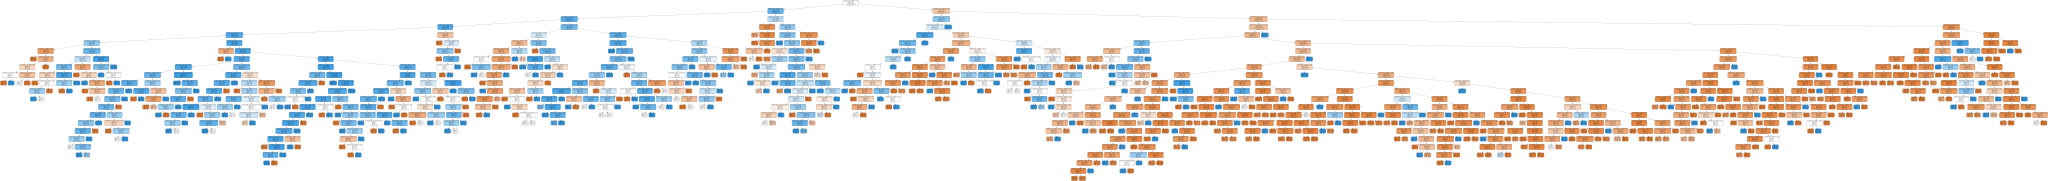

In [72]:
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import numpy as np # Ensure numpy is imported

# Train a Decision Tree model specifically for visualization
viz_tree_model = DecisionTreeClassifier( min_samples_leaf=1, min_samples_split=2)
# Train on the selected features
Xtrain = X_train_selected.toarray()
Xtest_sparse = X_test_selected # Keep the original sparse matrix if needed elsewhere
Xtest = X_test_selected.toarray() # Convert X_test_selected to a dense array for SHAP plotting

viz_tree_model.fit(Xtrain, yR3_train)

# Export the decision tree to a dot format string
dot_data = export_graphviz(viz_tree_model, out_file=None, filled=True, rounded=True, special_characters=True, feature_names=selected_features_names, class_names=['no', 'yes'])

# Create a graph from the dot data
graph = graphviz.Source(dot_data)

# Render the graph
graph

In [48]:
import shap
from sklearn.tree import DecisionTreeClassifier
import numpy as np


In [64]:
explainer = shap.TreeExplainer(viz_tree_model)

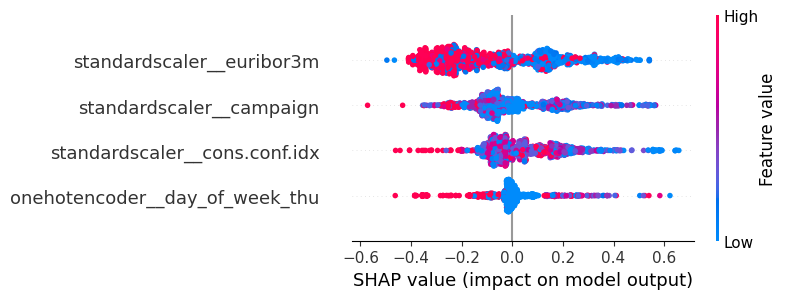

In [87]:

shap.initjs()
# Plot summary plot for the positive class (index 1)
shap.summary_plot(
    shap_values[:, :, 1], # SHAP values for the positive class (samples x features)
    features=Xtest, # Pass the feature values (samples x features)
    feature_names=selected_features_names,
    plot_type="dot" # Default plot type
)


In [88]:
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0,:,1], Xtest[0,:])

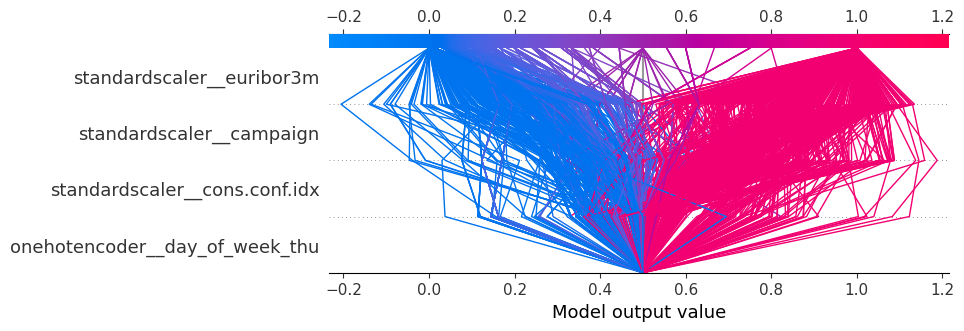

In [89]:
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import shap
import numpy as np # Ensure numpy is imported

# Re-initialize SHAP JavaScript visualization
shap.initjs()

# Select a feature name to plot dependence for.
feature_to_plot_name = selected_features_names[0]

# Find the index of this feature in the selected feature names
feature_to_plot_index = selected_features_names.index(feature_to_plot_name)




shap.decision_plot(
    explainer.expected_value[1], # Use expected value for the positive class
    shap_values[:, :, 1], # Use SHAP values for the positive class (index 1)
    feature_names=selected_features_names
)

Final Conclusion:

After ruling out Logarithmic Regression and SVM for poor results, we optimized K-Nearest Neighbors and Decision Tree classifiers. Key features included the Euribor 3-month rate, campaign call count, and consumer confidence index. Calling more than 3 or 4 times reduces success odds. The Euribor rate, a significant European interest benchmark, strongly correlates with the consumer price index and influences behavior. Students, retirees, and certain demographics show higher success rates, which fluctuate with interest rates. Prior negative credit behavior is exclusionary.